## **Five Number Summay Calcuation and Outlier Removal in Python**

In [17]:
import seaborn as sns
import numpy as np
import pandas as pd

In [2]:
lst_marks = [33,44,54,63,23,77,99,101,84,39,47,22,15,-10,211]
print(lst_marks)

[33, 44, 54, 63, 23, 77, 99, 101, 84, 39, 47, 22, 15, -10, 211]


`Minimum, Q1, Median (Q2), Q3,  Maximum`

In [4]:
## Five Number Summary
minimum, Q1, median, Q3, Maximum = np.quantile(lst_marks,[0.0,0.25,0.50,0.75,1.0])


In [12]:
print('minimum: ',minimum,'\nQ1: ',Q1,'\nMedian: ',median,'\nQ3: ',Q3,'\nMaximum: ',Maximum)

minimum:  -10.0 
Q1:  28.0 
Median:  47.0 
Q3:  80.5 
Maximum:  211.0


### now we plot a boxplot for outlier detection

<Axes: >

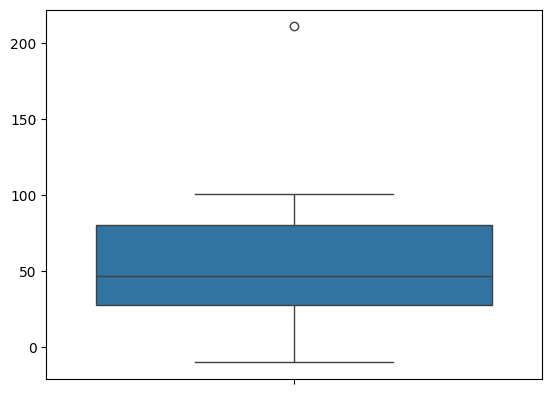

In [13]:
sns.boxplot(lst_marks)

* Here it is showing one outlier to `detect ` this outlier we will find `lower fence` and `higher fence `values

In [14]:
IQR = Q3- Q1
print(IQR)

52.5


In [15]:
lower_fence = Q1 - 1.5 * (IQR)
higher_fence = Q3 + 1.5 * (IQR)

print(lower_fence)
print(higher_fence)

-50.75
159.25


This show that the values below `-50` and the values above `159.25` are `Outliers`

In [16]:
## to identify the outliers in our data 
[x for x in lst_marks if x <-50 or x > 159]

[211]

`This show that we have only one value outlier which is 211`

### **Implimenting Five Number Summary and Outlier Removal on Real Dataset**

In [21]:
df = sns.load_dataset('titanic')

In [24]:
df['age'].fillna(df['age'].mean(),inplace=True)

C:\Users\PMYLS\AppData\Local\Temp\ipykernel_12508\1492264711.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(),inplace=True)


In [25]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [46]:
## Five Number Summary

min, Q1, median, Q3, max = np.quantile(df['age'],[0,0.25,.50,.75,1])

In [47]:
## OUTLIERS 

IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * (IQR)
higher_fence = Q3 + 1.5 * (IQR)

print(lower_fence)
print(higher_fence)

2.5
54.5


`Here you can see the  outliers `

In [52]:
df[(df['age'] <= lower_fence) | (df['age'] >= higher_fence)]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
7,0,3,male,2.00,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
11,1,1,female,58.00,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
15,1,2,female,55.00,0,0,16.0000,S,Second,woman,False,NaN,Southampton,yes,True
16,0,3,male,2.00,4,1,29.1250,Q,Third,child,False,NaN,Queenstown,no,False
33,0,2,male,66.00,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
827,1,2,male,1.00,0,2,37.0042,C,Second,child,False,NaN,Cherbourg,yes,False
829,1,1,female,62.00,0,0,80.0000,NaN,First,woman,False,B,NaN,yes,True
831,1,2,male,0.83,1,1,18.7500,S,Second,child,False,NaN,Southampton,yes,False
851,0,3,male,74.00,0,0,7.7750,S,Third,man,True,NaN,Southampton,no,True


<Axes: ylabel='age'>

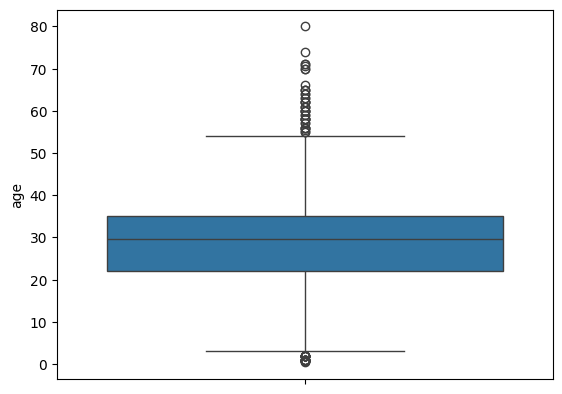

In [49]:
## boxplot 
sns.boxplot(df['age'])

#### To get the data with out outliers 

In [87]:
new_df = df[(df['age'] > 2.5) & (df['age'] < 54)]

In [91]:
new_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


(<Axes: ylabel='age'>, np.float64(53.0))

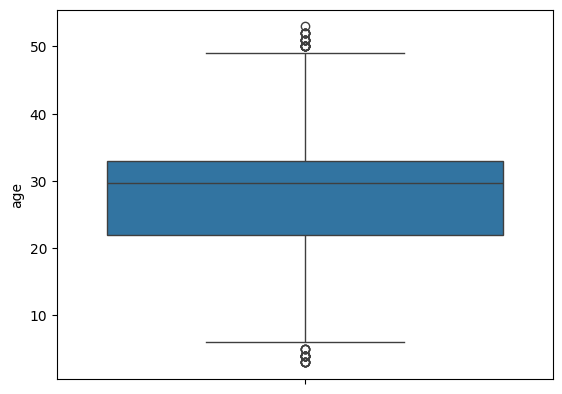

In [92]:
sns.boxplot(new_df['age']),new_df['age'].max()

In [93]:
new_df.shape

(817, 15)

In [94]:
new_df['age'].describe()

count    817.000000
mean      28.633713
std        9.922549
min        3.000000
25%       22.000000
50%       29.699118
75%       33.000000
max       53.000000
Name: age, dtype: float64

In [95]:
df['age'].describe()

count    891.000000
mean      29.699118
std       13.002015
min        0.420000
25%       22.000000
50%       29.699118
75%       35.000000
max       80.000000
Name: age, dtype: float64

### This is how we can remove the outliers in any dataset 